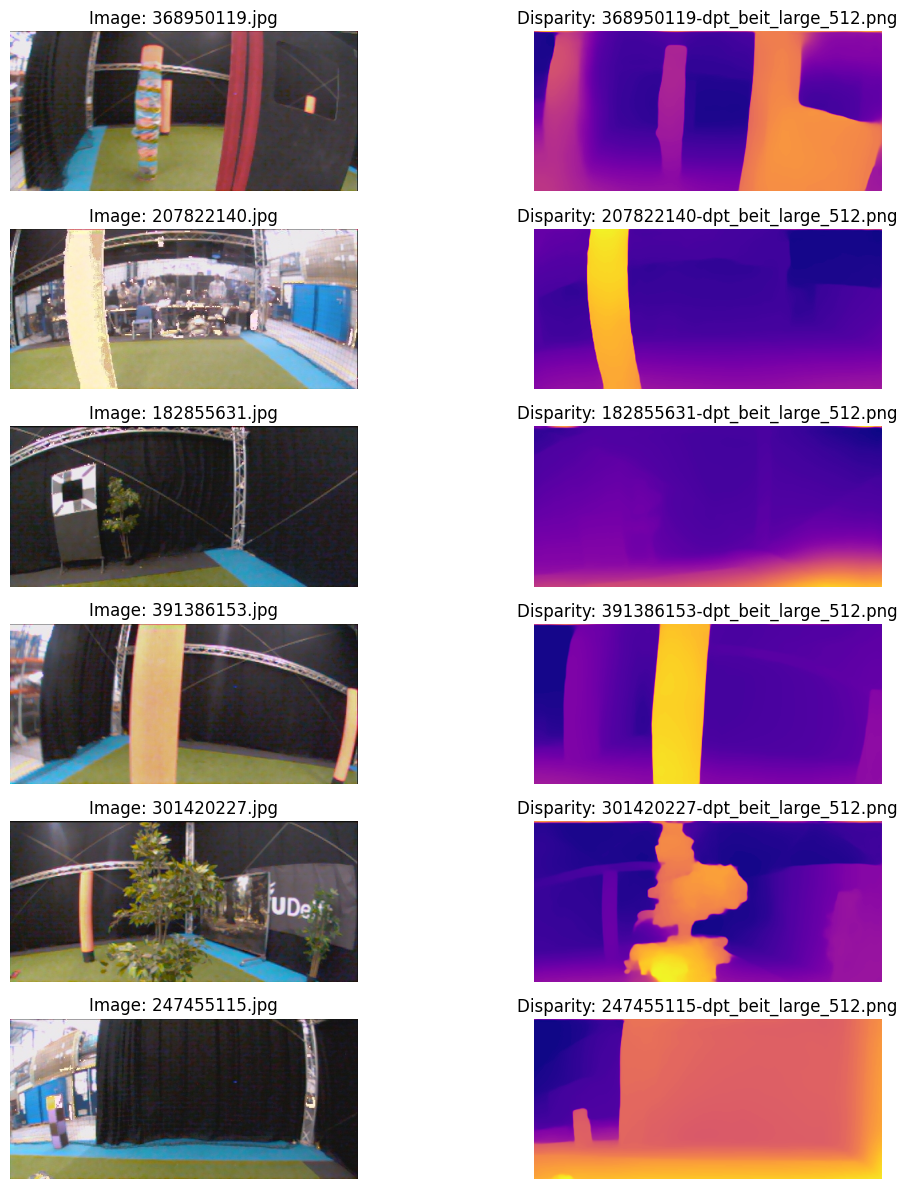

In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

def get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=6):
    random.seed(42)
    # Get all image and disparity file names
    image_files = sorted(os.listdir(image_folder))
    disparity_files = sorted(os.listdir(disparity_folder))
    
    # Create a mapping from disparity filenames to their corresponding image filenames
    disparity_map = {f.split('-')[0]: f for f in disparity_files}
    
    # Find matching pairs
    pairs = []
    for img_file in image_files:
        img_id = img_file.split('.')[0]  # Extract the ID from image filename
        if img_id in disparity_map:
            pairs.append((img_file, disparity_map[img_id]))
    
    # Randomly select num_pairs of them
    selected_pairs = random.sample(pairs, min(num_pairs, len(pairs)))
    return selected_pairs

def plot_image_disparity_pairs(image_folder, disparity_folder, pairs):
    plt.figure(figsize=(12, 12))
    
    for i, (image_file, disparity_file) in enumerate(pairs):
        # Read the image and disparity map
        img_path = os.path.join(image_folder, image_file)
        disparity_path = os.path.join(disparity_folder, disparity_file)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        disparity = cv2.imread(disparity_path, cv2.IMREAD_GRAYSCALE)
        
        # Plot Image
        plt.subplot(len(pairs), 2, 2 * i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image: {image_file}")
        
        # Plot Disparity
        plt.subplot(len(pairs), 2, 2 * i + 2)
        plt.imshow(disparity, cmap='plasma')  # Use a colormap to better visualize disparities
        plt.axis('off')
        plt.title(f"Disparity: {disparity_file}")
    
    plt.tight_layout()
    plt.show()

# Set folder paths
image_folder = 'images'
disparity_folder = 'disparities'

# Get image-disparity pairs
pairs = get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=6)

# Plot them
plot_image_disparity_pairs(image_folder, disparity_folder, pairs)


✅ labels.txt created with 1944 entries in 'labels.txt'
Pair 1: 469851055.jpg, 469851055-dpt_beit_large_512.png → Label: 0
Pair 2: 416919286.jpg, 416919286-dpt_beit_large_512.png → Label: 0
Pair 3: 343883695.jpg, 343883695-dpt_beit_large_512.png → Label: 1
Pair 4: 377986247.jpg, 377986247-dpt_beit_large_512.png → Label: 1
Pair 5: 41731062.jpg, 41731062-dpt_beit_large_512.png → Label: 1
Pair 6: 216022039.jpg, 216022039-dpt_beit_large_512.png → Label: 0


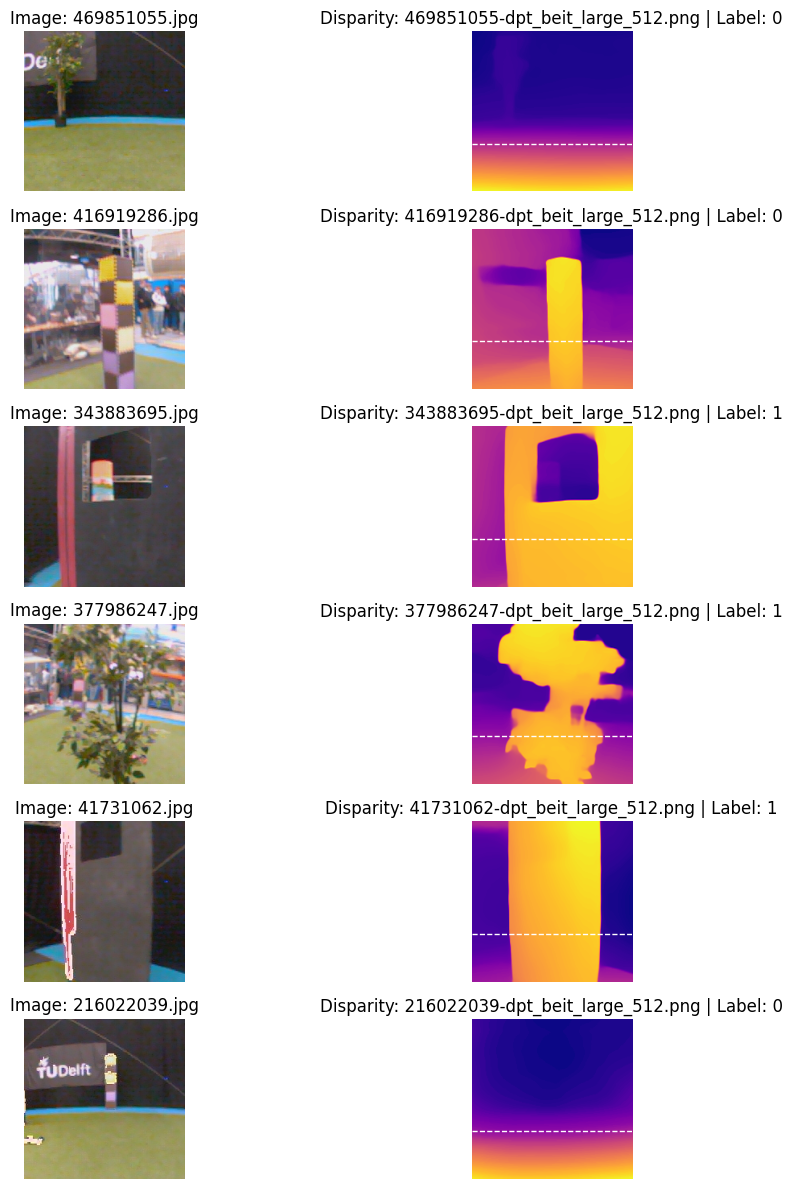

In [2]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

def get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=1944):
    # random.seed(42)
    image_files = sorted(os.listdir(image_folder))
    disparity_files = sorted(os.listdir(disparity_folder))
    
    disparity_map = {f.split('-')[0]: f for f in disparity_files}
    
    pairs = []
    for img_file in image_files:
        img_id = img_file.split('.')[0]
        if img_id in disparity_map:
            pairs.append((img_file, disparity_map[img_id]))
    
    return random.sample(pairs, min(num_pairs, len(pairs)))

def center_crop(image, crop_size=200):
    h, w = image.shape[:2]
    start_x = w // 2 - crop_size // 2
    start_y = h // 2 - crop_size // 2
    return image[start_y:start_y + crop_size, start_x:start_x + crop_size]

def assign_collision_label(disparity, threshold=150, ratio=0.05, top_fraction=0.7):
    """
    Assign label 1 if more than `ratio` of pixels in the TOP part of the image
    have disparity > `threshold`. This avoids false positives from ground surfaces.
    """
    h = disparity.shape[0]
    top_h = int(h * top_fraction)
    top_disparity = disparity[:top_h, :]

    valid = top_disparity > 0
    close_pixels = (top_disparity > threshold) & valid

    if np.sum(valid) == 0:
        return 0  # Avoid divide-by-zero

    collision_ratio = np.sum(close_pixels) / np.sum(valid)
    return int(collision_ratio > ratio)

def save_collision_labels(image_folder, disparity_folder, output_file):
    pairs = get_image_disparity_pairs(image_folder, disparity_folder)

    with open(output_file, 'w') as f:
        f.write("Collision Probability,Filename\n")  # Write header
        
        for img_file, disparity_file in pairs:
            disparity_path = os.path.join(disparity_folder, disparity_file)
            disparity = cv2.imread(disparity_path, cv2.IMREAD_GRAYSCALE)
            disparity_cropped = center_crop(disparity)
            
            # Get collision probability
            collision_prob = assign_collision_label(disparity_cropped)
            collision_prob = float(collision_prob)
            
            # Write to file
            f.write(f"{collision_prob},{img_file}\n")
    
    print(f"✅ labels.txt created with {len(pairs)} entries in '{output_file}'")

def plot_image_disparity_pairs(image_folder, disparity_folder, pairs):
    plt.figure(figsize=(12, 12))
    
    for i, (image_file, disparity_file) in enumerate(pairs):
        img_path = os.path.join(image_folder, image_file)
        disparity_path = os.path.join(disparity_folder, disparity_file)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_cropped = center_crop(img)
        
        disparity = cv2.imread(disparity_path, cv2.IMREAD_GRAYSCALE)
        disparity_cropped = center_crop(disparity)
        
        label = assign_collision_label(disparity_cropped)

        print(f"Pair {i+1}: {image_file}, {disparity_file} → Label: {label}")
        
        # Plot cropped image
        plt.subplot(len(pairs), 2, 2 * i + 1)
        plt.imshow(img_cropped)
        plt.axis('off')
        plt.title(f"Image: {image_file}")
        
        # Plot cropped disparity with top region overlay
        plt.subplot(len(pairs), 2, 2 * i + 2)
        plt.imshow(disparity_cropped, cmap='plasma')
        # Draw horizontal line to show top region used
        top_h = int(disparity_cropped.shape[0] * 0.7)
        plt.axhline(y=top_h, color='white', linestyle='--', linewidth=1)
        plt.axis('off')
        plt.title(f"Disparity: {disparity_file} | Label: {label}")
    
    plt.tight_layout()
    plt.show()

# Paths
image_folder = 'images'
disparity_folder = 'disparities'
output_file = 'labels.txt'

# Run
save_collision_labels(image_folder, disparity_folder, output_file)
pairs = get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=6)
plot_image_disparity_pairs(image_folder, disparity_folder, pairs)


Pair 1: 396752779.jpg, Steering: -0.69
Pair 2: 380819557.jpg, Steering: 0.03
Pair 3: 343386518.jpg, Steering: -0.49
Pair 4: 340217041.jpg, Steering: -0.54
Pair 5: 365350150.jpg, Steering: 0.51
Pair 6: 177022424.jpg, Steering: -0.06


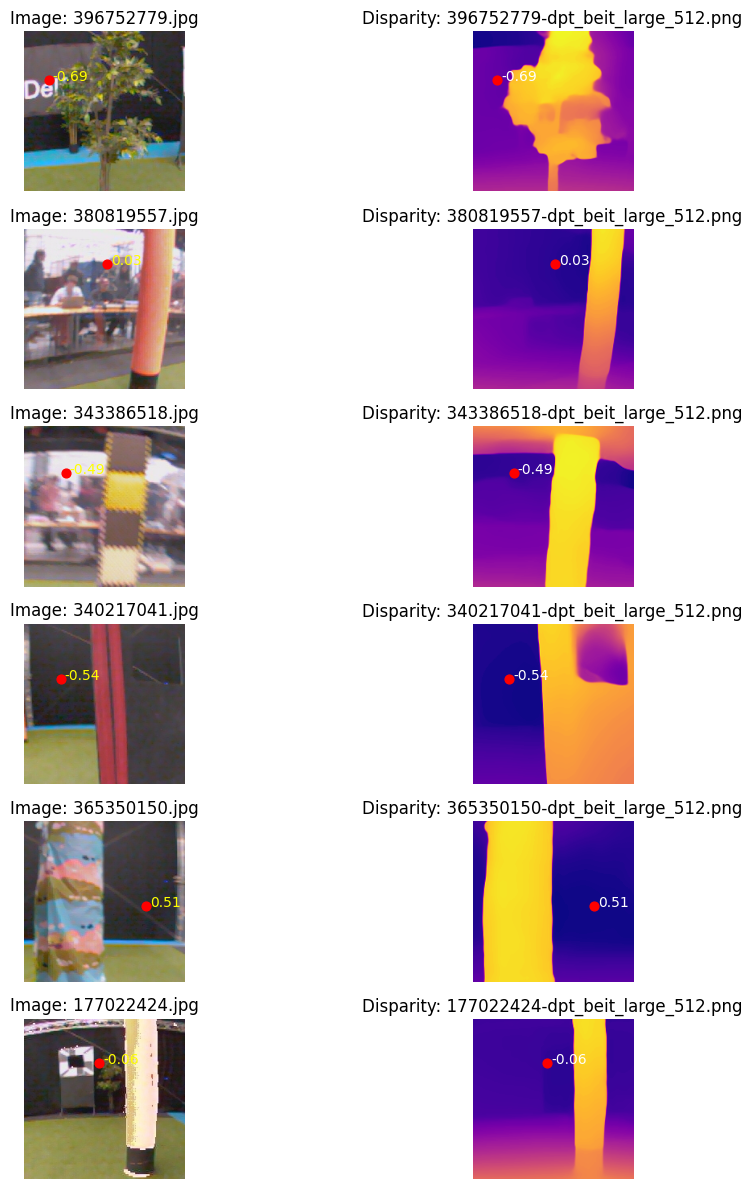

In [27]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
from scipy.ndimage import label, center_of_mass

def get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=6):
    # random.seed(42)
    image_files = sorted(os.listdir(image_folder))
    disparity_files = sorted(os.listdir(disparity_folder))
    
    disparity_map = {f.split('-')[0]: f for f in disparity_files}
    
    pairs = []
    for img_file in image_files:
        img_id = img_file.split('.')[0]
        if img_id in disparity_map:
            pairs.append((img_file, disparity_map[img_id]))
    
    return random.sample(pairs, min(num_pairs, len(pairs)))

def center_crop(image, crop_size=200):
    h, w = image.shape[:2]
    start_x = w // 2 - crop_size // 2
    start_y = h // 2 - crop_size // 2
    return image[start_y:start_y + crop_size, start_x:start_x + crop_size]

def get_steering_from_disparity(disparity, low_percentile=20):
    """
    Assigns a steering label [-1, 1] based on the horizontal position of the
    centroid of the farthest region (lowest disparity).
    """
    # Mask: where disparity is among the lowest X% (farthest)
    threshold = np.percentile(disparity[disparity > 0], low_percentile)
    mask = (disparity > 0) & (disparity <= threshold)

    # Label connected regions
    labeled, num_features = label(mask)
    if num_features == 0:
        return 0.0, None  # default center steering if nothing is far

    # Find the largest region
    region_sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
    largest_region_label = np.argmax(region_sizes) + 1
    region_mask = labeled == largest_region_label

    # Compute centroid of the region
    centroid_y, centroid_x = center_of_mass(region_mask)

    # Normalize centroid_x to range [-1, 1]
    w = disparity.shape[1]
    steering = 2 * (centroid_x / w) - 1  # -1 = far left, 1 = far right
    return steering, (int(centroid_x), int(centroid_y))

def plot_steering_labels(image_folder, disparity_folder, pairs):
    plt.figure(figsize=(12, 12))
    
    for i, (image_file, disparity_file) in enumerate(pairs):
        img_path = os.path.join(image_folder, image_file)
        disparity_path = os.path.join(disparity_folder, disparity_file)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_cropped = center_crop(img)
        
        disparity = cv2.imread(disparity_path, cv2.IMREAD_GRAYSCALE)
        disparity_cropped = center_crop(disparity)
        
        steering, centroid = get_steering_from_disparity(disparity_cropped)

        print(f"Pair {i+1}: {image_file}, Steering: {steering:.2f}")

        # Plot image
        plt.subplot(len(pairs), 2, 2 * i + 1)
        plt.imshow(img_cropped)
        if centroid:
            plt.scatter(*centroid, color='red', s=40)
            plt.text(centroid[0]+5, centroid[1], f"{steering:.2f}", color='yellow', fontsize=10)
        plt.axis('off')
        plt.title(f"Image: {image_file}")
        
        # Plot disparity
        plt.subplot(len(pairs), 2, 2 * i + 2)
        plt.imshow(disparity_cropped, cmap='plasma')
        if centroid:
            plt.scatter(*centroid, color='red', s=40)
            plt.text(centroid[0]+5, centroid[1], f"{steering:.2f}", color='white', fontsize=10)
        plt.axis('off')
        plt.title(f"Disparity: {disparity_file}")
    
    plt.tight_layout()
    plt.show()

# Paths
image_folder = 'images'
disparity_folder = 'disparities'

# Run
pairs = get_image_disparity_pairs(image_folder, disparity_folder, num_pairs=6)
plot_steering_labels(image_folder, disparity_folder, pairs)


In [28]:
output_file = 'sync_steering.txt'

def save_steering_to_file(image_folder, disparity_folder, output_file):
    image_files = sorted(os.listdir(image_folder))
    disparity_files = sorted(os.listdir(disparity_folder))
    
    disparity_map = {f.split('-')[0]: f for f in disparity_files}
    
    pairs = []
    for img_file in image_files:
        img_id = img_file.split('.')[0]
        if img_id in disparity_map:
            pairs.append((img_file, disparity_map[img_id]))

    # Open the output file for writing
    with open(output_file, 'w') as f:
        f.write("Steering Value,Filename\n")  # Write header
        
        for img_file, disparity_file in pairs:
            img_path = os.path.join(image_folder, img_file)
            disparity_path = os.path.join(disparity_folder, disparity_file)
            
            disparity = cv2.imread(disparity_path, cv2.IMREAD_GRAYSCALE)
            disparity_cropped = center_crop(disparity)
            
            # Extract only the steering value (ignore centroid)
            steering, _ = get_steering_from_disparity(disparity_cropped)
            steering = round(steering, 3)
            
            # Write to file: steering value, image filename
            f.write(f"{steering},{img_file}\n")  
    
    print(f"✅ sync_steering.txt created with {len(pairs)} entries in '{output_file}'")

# Generate steering values from disparity maps
save_steering_to_file(image_folder, disparity_folder, output_file)


✅ sync_steering.txt created with 1944 entries in 'sync_steering.txt'
